In [1]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

Config initialised in 0.0019 seconds


/Users/cristianzuniga/Documents/data_shepherd/src/data_shepherd/regions.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

IKEA_ISOS.sort()

In [3]:
REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')

## Load data

In [4]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [5]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [6]:
#dscale_results = pyam.IamDataFrame(DSCALE_PATH /  'outputs/week_2025_12_15/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2025_12_19_test_2022_harmo_step5e_None.csv')
dscale_results = pyam.IamDataFrame('/Users/cristianzuniga/Documents/DSCALE/DSCALE/results/5_Explorer_and_New_Variables/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2025_12_12_test_2022_harmo_step5e_None.csv')

[INFO] 15:42:37 - pyam.core: Reading file /Users/cristianzuniga/Documents/DSCALE/DSCALE/results/5_Explorer_and_New_Variables/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2025_12_12_test_2022_harmo_step5e_None.csv


In [7]:
df_primap_raw = pd.read_csv(DSCALE_PATH /  'data/step1_input_data_for_DSCALE/Guetschow_et_al_2025a-PRIMAP-hist_v2.7_final_no_extrap_no_rounding_22-Aug-2025.csv')

# PLOTTING DATA

        1.- Country|Sector|Emissions|CO2 from energy demand

<Axes: title={'center': 'model: REMIND-MAgPIE 3.3-4.8 - region: CHL - variable: Final Energy|Electricity'}, xlabel='Year', ylabel='EJ/yr'>

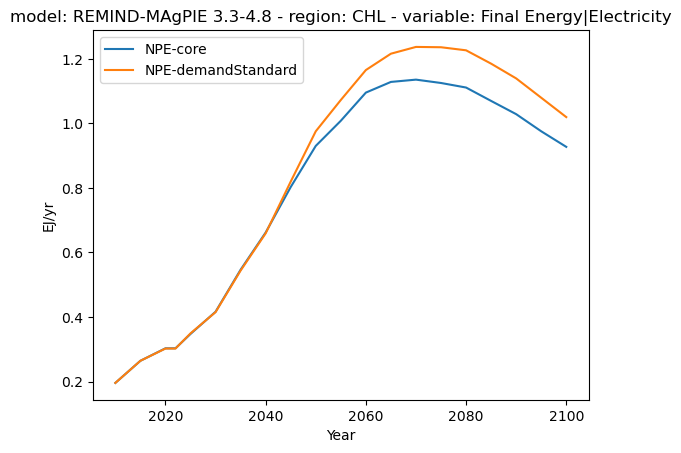

In [109]:
dscale_results.filter(variable= 'Final Energy|Electricity', level=1, region="CHL").plot()

In [104]:
dscale_results.filter(variable= 'Final Energy|Transportation|Rail*')

<class 'pyam.core.IamDataFrame'>
Index:
 * model    : REMIND-MAgPIE 3.3-4.8 (1)
 * scenario : NPE-core, NPE-demandStandard (2)
Timeseries data coordinates:
   region   : IND, JPN, USA (3)
   variable : Final Energy|Transportation|Rail, ... (3)
   unit     : EJ/yr (1)
   year     : 2010, 2015, 2020, 2022, 2025, 2030, 2035, 2040, ... 2100 (20)

<Axes: title={'center': 'model: REMIND-MAgPIE 3.3-4.8 scenario: NPE-core region: CHL'}, xlabel='Year', ylabel='EJ/yr'>

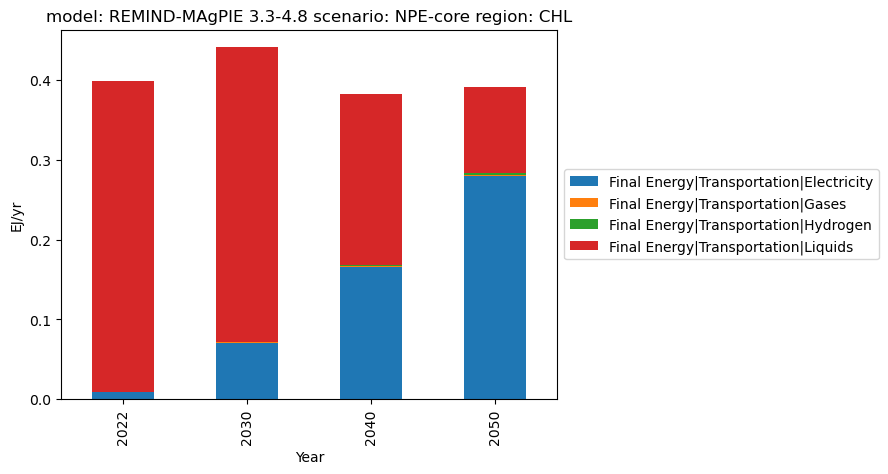

In [98]:
dscale_results.filter(variable= 'Final Energy|Transportation*', level=1, scenario= "NPE-core", region="CHL", year=[2022, 2030, 2040, 2050]).plot.bar(stacked=True)

In [8]:
# Pre-proccesing PRIMAP data 
df_primap_pyam = pyam.IamDataFrame(
    df_primap_raw.rename(
        columns={
            'source':'model',
            'scenario (PRIMAP-hist)':'scenario',
            'area (ISO3)':'region',
            'entity':'variable',
            'category (IPCC2006_PRIMAP)':'category'
        }
    )
)

# Sector selection
df_primap_co2_energy = df_primap_pyam.filter(
    variable='CO2',
    category='1', #Filter out the Energy sector
    scenario="HISTCR"
)

df_primap_co2_energy.rename(unit={"CO2 * gigagram / a" : "Gg CO2/yr"}, inplace=True)

In [9]:
sector_co2 = dscale_results.filter(scenario= "NPE-core", variable='Emissions|CO2|Energy').interpolate(time=range(2010,2101,1))

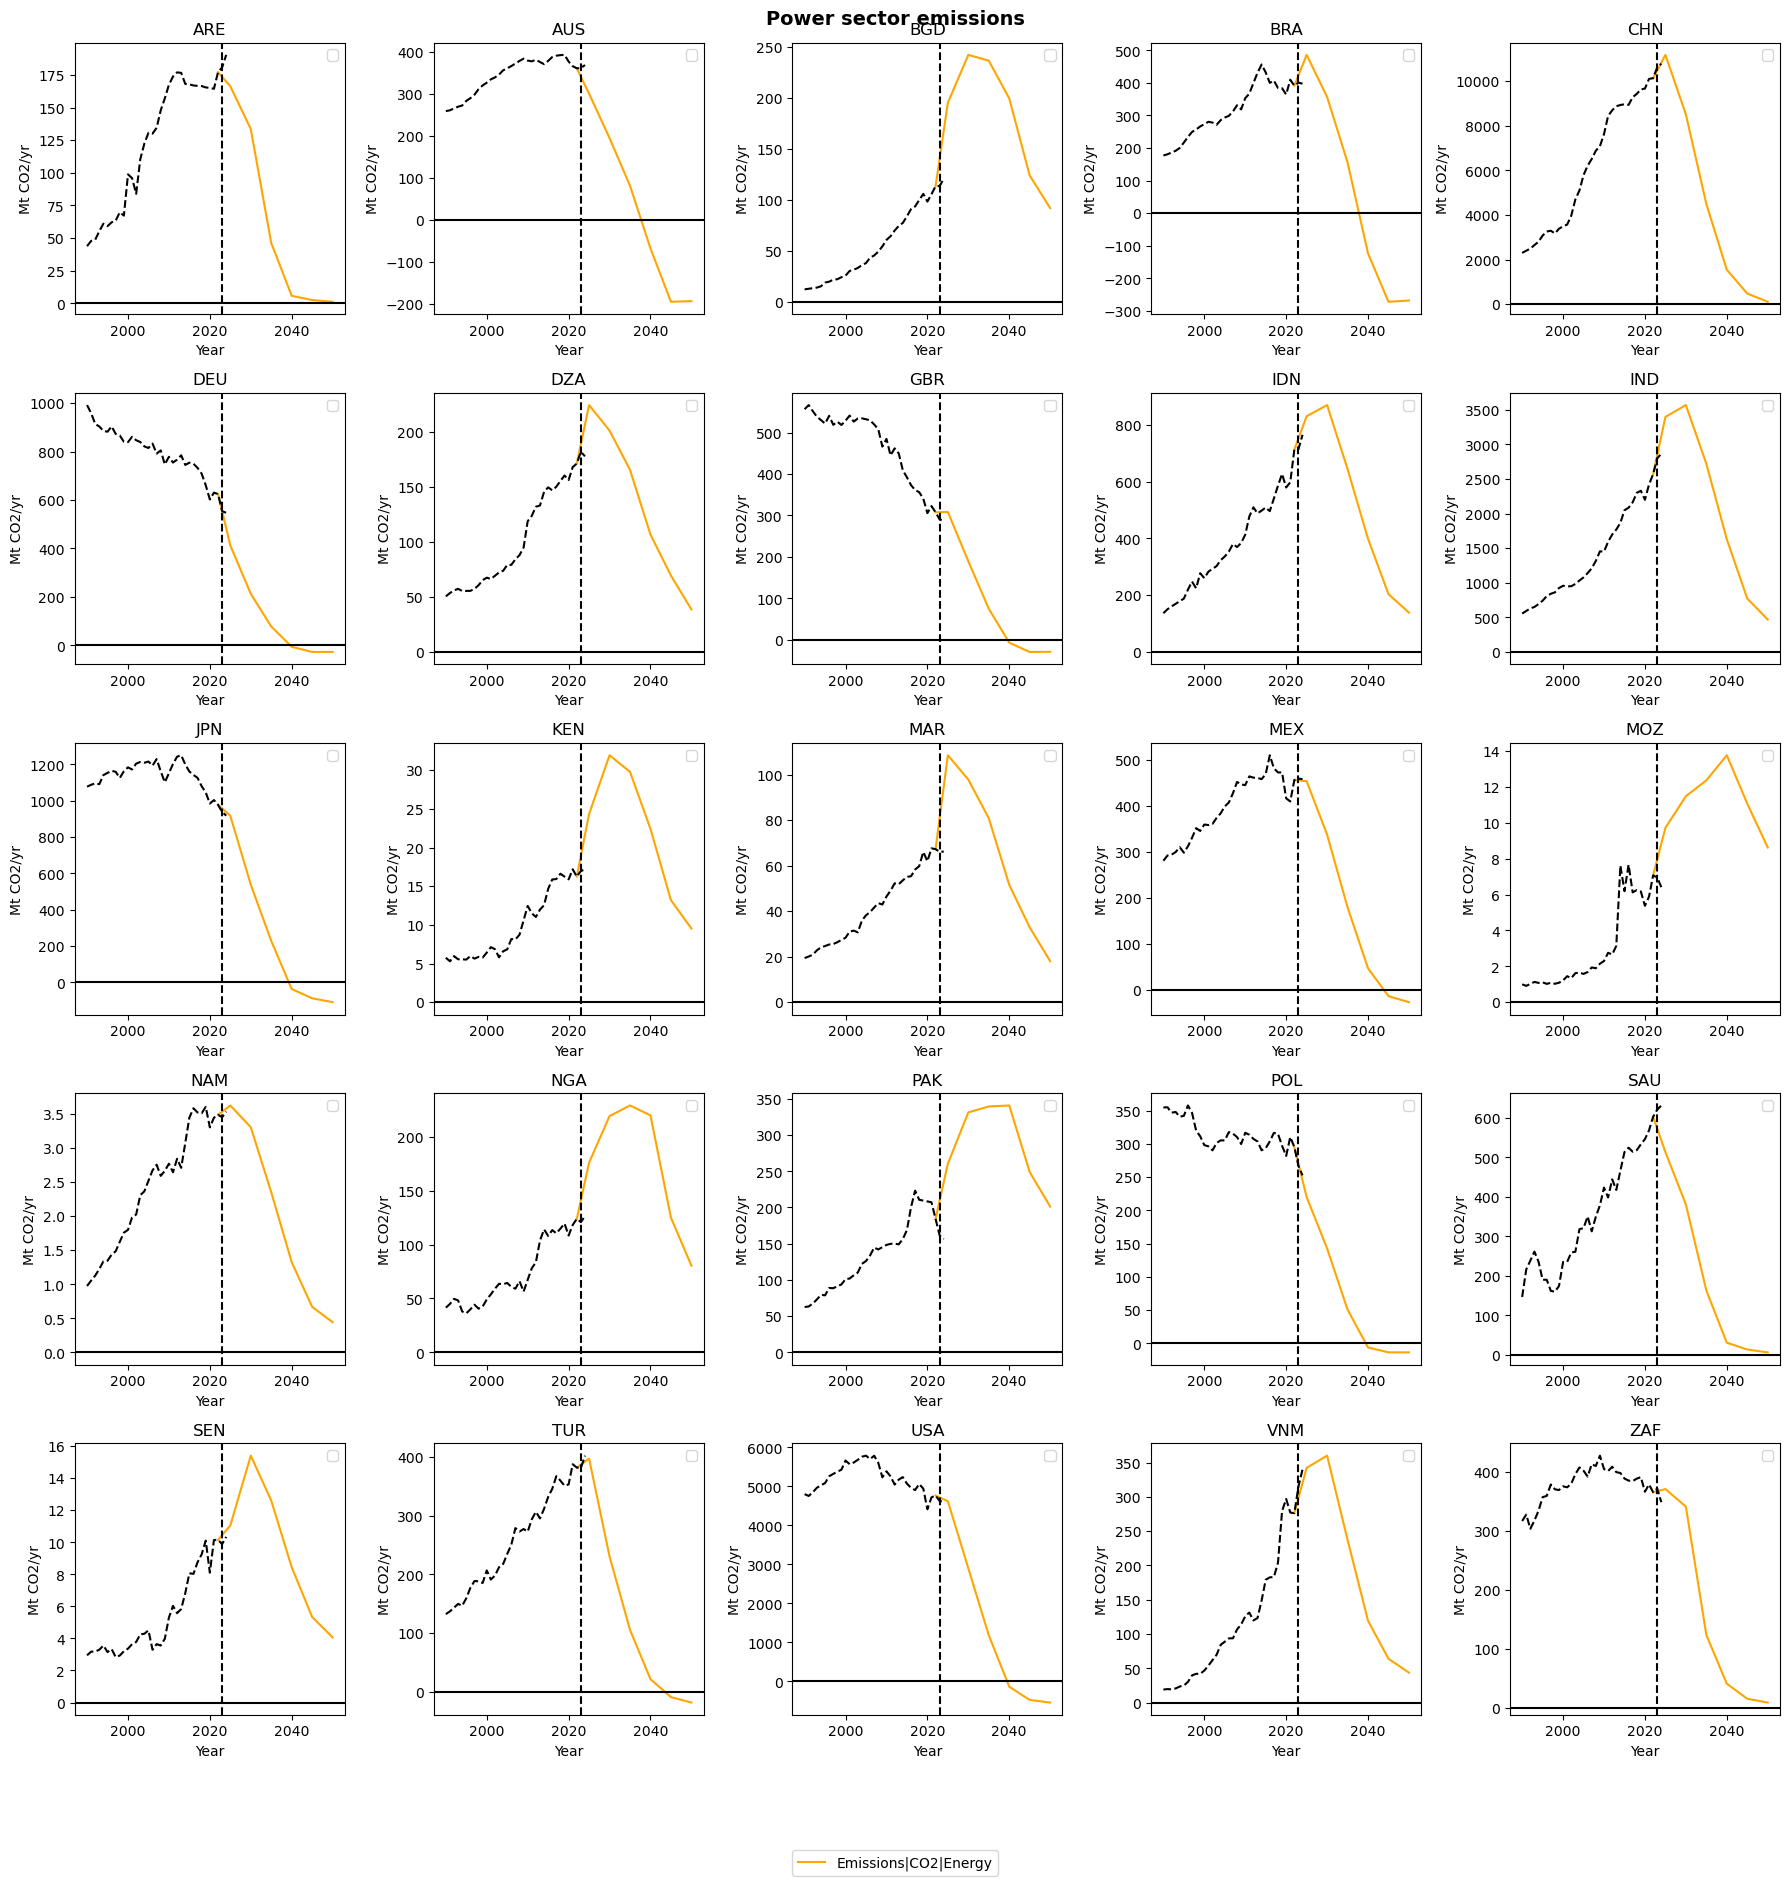

In [117]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
elec_vars = ["Emissions|CO2|Energy"]

for count, ax in enumerate(axes.ravel()[:]):
    dscale_results.filter(scenario="NPE-core",region=IKEA_ISOS[count],variable=elec_vars,year=range(2022,2051)).convert_unit('EJ/yr','TWh / yr').plot(ax=ax, color="orange")
    df_primap_co2_energy.filter(region=IKEA_ISOS[count],year=range(1990, 2025)).convert_unit('EJ/yr','TWh / yr').convert_unit('Gg CO2/yr', to='Mt CO2/yr').plot(ax=ax,color='k',lw=1.5, linestyle="--")
    
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle('Power sector emissions',fontsize=14,fontweight='bold')
f.legend(elec_vars,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

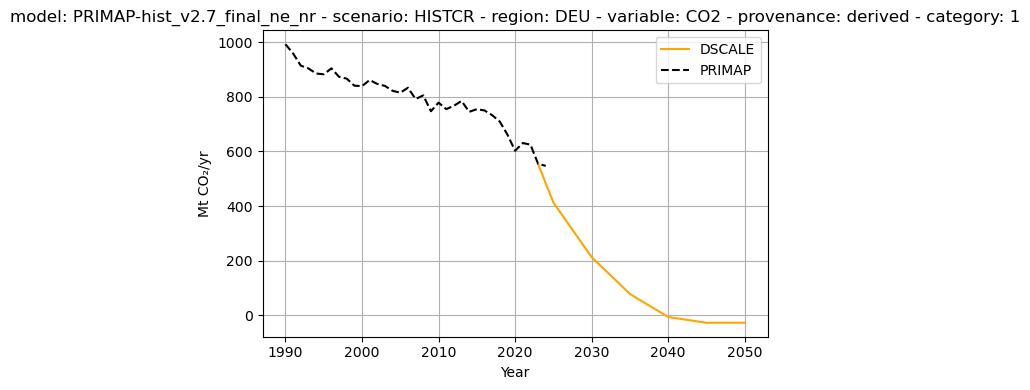

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

sector_co2.filter(
    region='DEU',
    year=range(2023,2051)
).plot(ax=ax, label='DSCALE', color="orange")

df_primap_co2_energy.filter(
    region='DEU', 
    year=range(1990, 2025)
).convert_unit(
    'Gg CO2/yr', to='Mt CO2/yr'
).plot(ax=ax, label='PRIMAP', linestyle="--", color="black")

ax.set_ylabel("Mt CO₂/yr")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

        2.- Country´s energy mix per Sector

In [12]:
dscale_results.aggregate(
    'Secondary Energy|Electricity|Renewables incl. biomass', 
    ['Secondary Energy|Electricity|Biomass|w/o CCS',
    'Secondary Energy|Electricity|Hydro',
    #'Secondary Energy|Electricity|Geothermal',
    'Secondary Energy|Electricity|Solar',
    'Secondary Energy|Electricity|Wind',
], append=True
) 

In [22]:
dscale_results.filter(variable= 'Secondary Energy|Electricity|Renewables incl. biomass').unit

['EJ/yr']

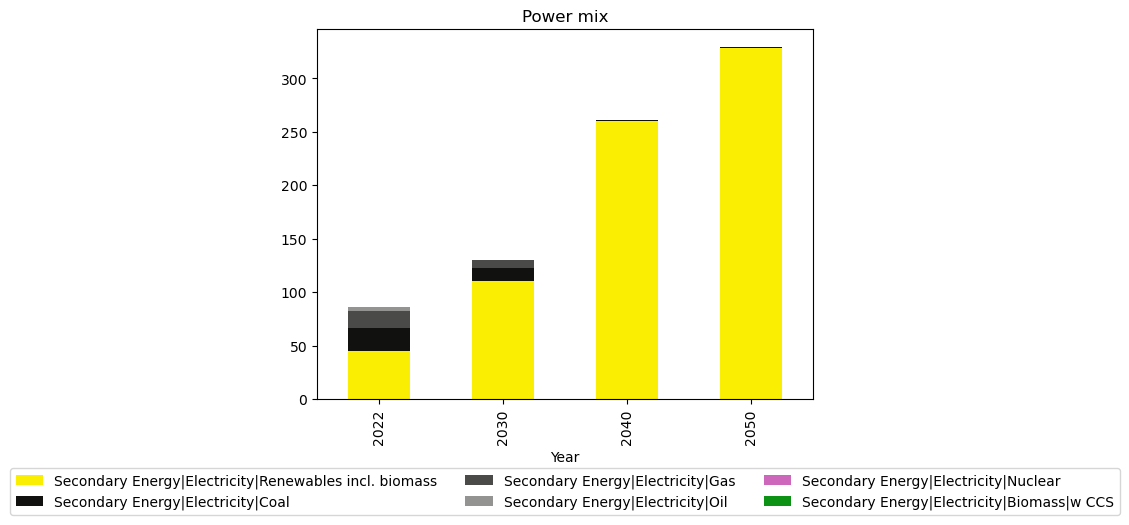

In [56]:

color_map = {
   'Secondary Energy|Electricity|Renewables incl. biomass': "#faee02",
   'Secondary Energy|Electricity|Coal':"#111110",
   'Secondary Energy|Electricity|Gas': "#4A4A49",
    'Secondary Energy|Electricity|Biomass|w CCS': "#0e9215",
    'Secondary Energy|Electricity|Oil': "#939391",
    'Secondary Energy|Electricity|Nuclear': "#cd67bb",
}

pyam.run_control().update({"color": {"variable": color_map}})

dscale_results.filter(
    scenario= 'NPE-core', 
    region="CHL",
    year=[2022, 2030, 2040, 2050]
).convert_unit('EJ/yr', to= "TWh/yr").plot.bar(stacked=True, 
              title="Power mix", 
              bars_order= ['Secondary Energy|Electricity|Renewables incl. biomass', 
                       'Secondary Energy|Electricity|Coal',
                       'Secondary Energy|Electricity|Gas',
                       #'Secondary Energy|Electricity|Trade',
                       'Secondary Energy|Electricity|Oil',
                       'Secondary Energy|Electricity|Nuclear',
                       'Secondary Energy|Electricity|Biomass|w CCS'
                       ])

#plt.set_ylabel("TWh/yr")
plt.legend(ncols=3,loc='center',bbox_to_anchor=[0.5,-.25])
#plt.tight_layout()
plt.show()

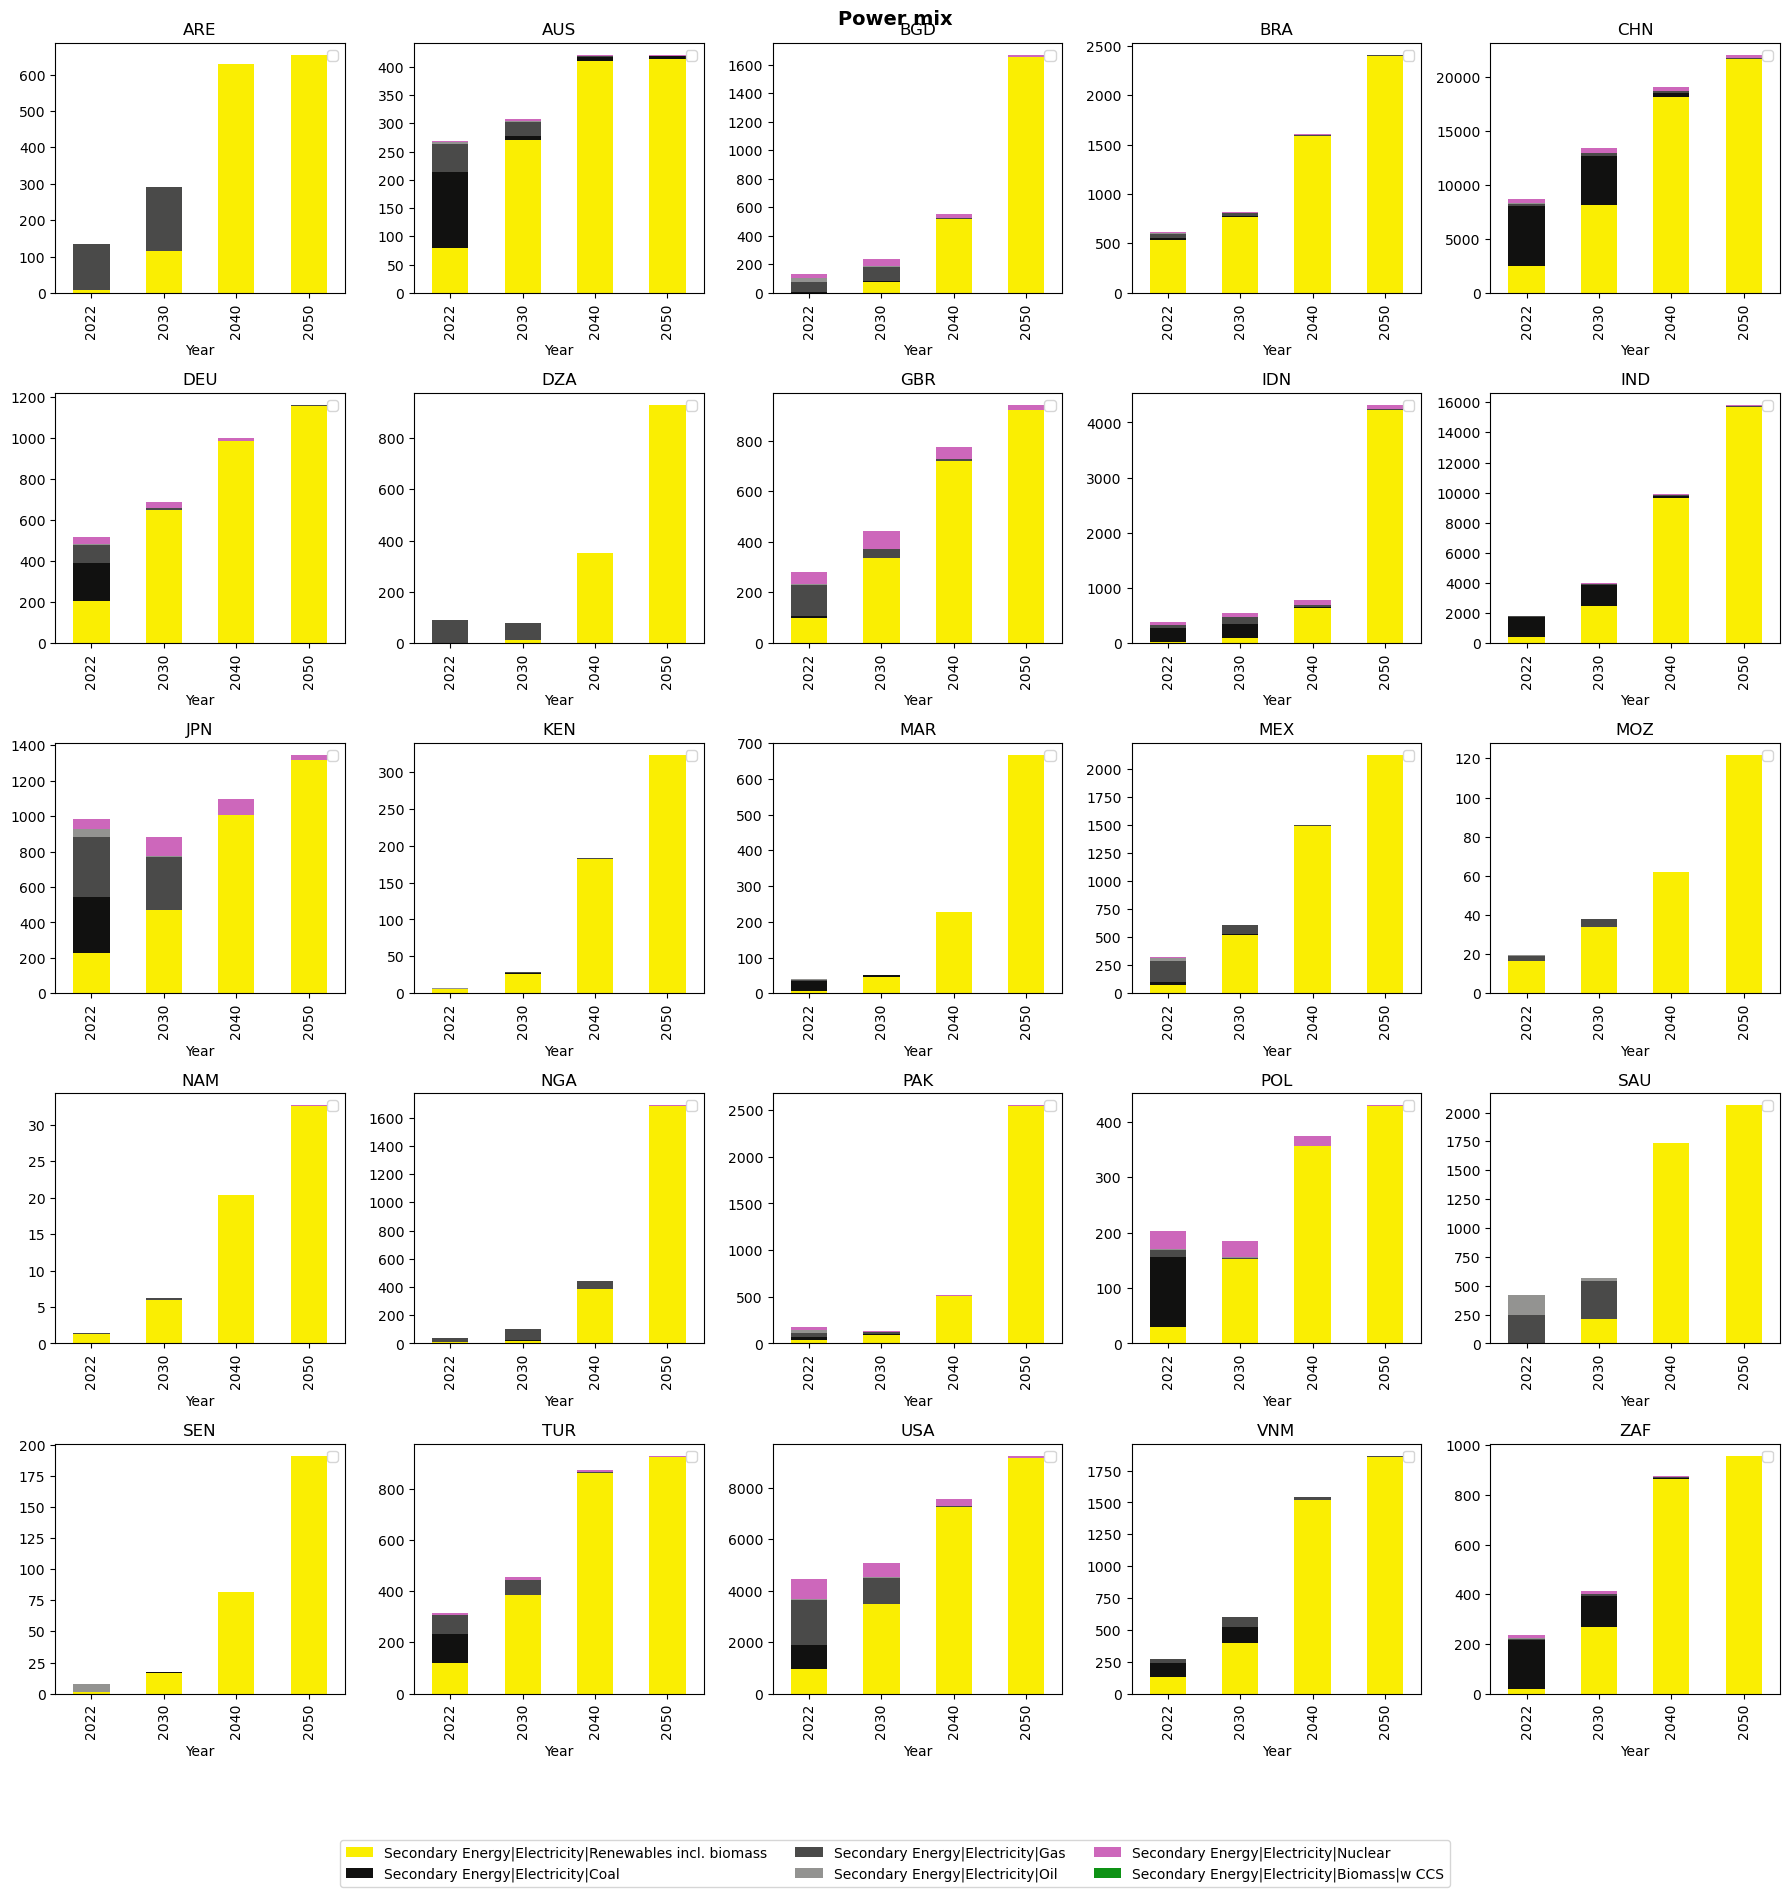

In [121]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
elec_vars = ['Secondary Energy|Electricity|Renewables incl. biomass', 
            'Secondary Energy|Electricity|Coal',
            'Secondary Energy|Electricity|Gas',
            #'Secondary Energy|Electricity|Trade',
            'Secondary Energy|Electricity|Oil',
            'Secondary Energy|Electricity|Nuclear',
            'Secondary Energy|Electricity|Biomass|w CCS'
        ]

color_map = {
   'Secondary Energy|Electricity|Renewables incl. biomass': "#faee02",
   'Secondary Energy|Electricity|Coal':"#111110",
   'Secondary Energy|Electricity|Gas': "#4A4A49",
    'Secondary Energy|Electricity|Biomass|w CCS': "#0e9215",
    'Secondary Energy|Electricity|Oil': "#939391",
    'Secondary Energy|Electricity|Nuclear': "#cd67bb",
}

for count, ax in enumerate(axes.ravel()[:]):
    dscale_results.filter(
    scenario= 'NPE-core', 
    region=IKEA_ISOS[count],
    year=[2022, 2030, 2040, 2050]
    ).convert_unit('EJ/yr', to= "TWh/yr").plot.bar(ax=ax,stacked=True, 
              title="Power mix", 
              bars_order= ['Secondary Energy|Electricity|Renewables incl. biomass', 
                       'Secondary Energy|Electricity|Coal',
                       'Secondary Energy|Electricity|Gas',
                       #'Secondary Energy|Electricity|Trade',
                       'Secondary Energy|Electricity|Oil',
                       'Secondary Energy|Electricity|Nuclear',
                       'Secondary Energy|Electricity|Biomass|w CCS'
                       ])   

    #ax.axvline(x=2023,color='k',ls='--')
    #ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle('Power mix',fontsize=14,fontweight='bold')
f.legend(elec_vars,ncols=3,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

        3.- Country´s reneable electricity investments and capacities

In [51]:
# Investment data only available for IND, JPN, and USA
dscale_results.filter(variable="Investment|Energy Supply|Electricity|*").region

['IND', 'JPN', 'USA']